## 1. Business Problem / Project Overview

The goal of this project is to predict whether a client will subscribe to a term deposit based on customer information and past marketing campaign data. This is a binary classification problem where the target variable indicates whether the client subscribed or not.

This task is important because improving prediction accuracy can help banks target more relevant customers, reduce marketing costs, and increase campaign efficiency.

In this analysis, we explore the dataset, preprocess the features, train several machine learning models, and compare their performance to identify the most effective approach.

###  Data Understanding

- The dataset used in this project comes from a bank marketing campaign and contains information about clients contacted regarding a term deposit subscription.
- Each row represents one customer, and the target variable `y` indicates whether the customer subscribed (`yes`) or not (`no`).
- The dataset includes both numerical and categorical features describing customer characteristics, financial status, and campaign interactions.
- Understanding the dataset is important before modeling because it helps identify feature types, missing values, class imbalance, and preprocessing requirements.


## Feature Description

- `age`: Age of the customer  
- `job`: Type of job held by the customer  
- `marital`: Marital status of the customer  
- `education`: Education level of the customer  
- `default`: Whether the customer has credit in default  
- `housing`: Whether the customer has a housing loan  
- `loan`: Whether the customer has a personal loan  
- `contact`: Whether the customer was contacted 
- `month`: Month of the last contact with the customer  
- `duration`: Duration of the last contact, in seconds  
- `campaign`: Number of contacts performed during the current campaign for this customer  
- `pdays`: Number of days since the customer was last contacted in a previous campaign; `999` means the customer was not previously contacted  
- `previous`: Number of contacts performed before the current campaign  
- `poutcome`: Outcome of the previous marketing campaign  
- `y`: Target variable indicating whether the customer subscribed to the term deposit  

## 2. Imports

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,average_precision_score,classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score,
    PrecisionRecallDisplay,precision_score,recall_score,RocCurveDisplay,roc_auc_score,)
from sklearn.model_selection import (GridSearchCV,RandomizedSearchCV,train_test_split,)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils import resample

In [33]:
DATA_PATH = Path("../data/bank-full.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}."
    )


In [34]:
df = pd.read_csv(DATA_PATH, sep=";")
print(f"Shape: {df.shape}")
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Data overview and target distribution

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [36]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


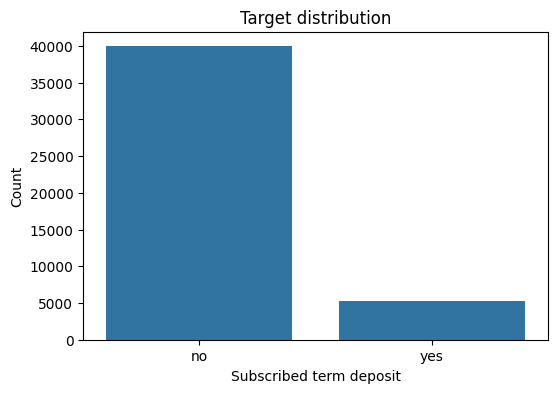

y
no     39922
yes     5289
Name: count, dtype: int64


In [37]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="y", ax=ax)
ax.set_title("Target distribution")
ax.set_xlabel("Subscribed term deposit")
ax.set_ylabel("Count")
plt.show()

counts = df["y"].value_counts()
print(counts)

### Target Variable Distribution

- The distribution of the target variable shows a strong class imbalance.
- The majority of customers belong to the `no` class, while the `yes` class represents a much smaller share of the dataset.
- This indicates that the prediction task is imbalanced, which can affect model performance.
- Because of this, model evaluation should not rely only on accuracy.
- Metrics such as precision, recall, F1-score, and ROC-AUC are more appropriate for assessing performance in this case.

## 4. Data quality review and leakage check

A critical issue in this dataset is the duration feature. It describes call duration and is usually only fully known after the call finishes.  
If the bank wants to decide who to contact before calling, duration causes target leakage.

We therefore exclude duration from modeling and keep it only for discussion if needed.

In [38]:
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0])

df_model = df.copy()
df_model = df_model.drop(columns='duration')

Series([], dtype: int64)

### Feature Engineering 

- To improve the representation of the data, a few simple features were created from the original variables.
- `age_band` was introduced to group customers into meaningful age ranges and make age-related patterns easier to interpret.
- `is_contacted_before` was created to identify whether a customer had any prior campaign contact history.
- `was_previously_successful` was added to capture whether earlier contact with the customer resulted in a successful outcome.
- These features provide information that may help the models detect patterns more effectively.


In [39]:
df_model["target"] = (df_model["y"] == "yes").astype(int)
df_model = df_model.drop(columns=["y"])

df_model["age_band"] = pd.cut(
    df_model["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

if "pdays" in df_model.columns:
    df_model["is_contacted_before"] = (df_model["pdays"] >= 0).astype(int)
else:
    df_model["is_contacted_before"] = 0

if "poutcome" in df_model.columns:
    df_model["was_previously_successful"] = (df_model["poutcome"] == "success").astype(int)
else:
    df_model["was_previously_successful"] = 0

df_model.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,target,age_band,is_contacted_before,was_previously_successful
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,0,56-65,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,0,36-45,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,0,26-35,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,0,46-55,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,0,26-35,0,0


## 5. Exploratory Analysis

#### Age Distribution

- The age distribution shows that most customers are concentrated in the adult and middle-age groups, with fewer observations at very young or older ages.
- In both classes, the largest number of customers appears roughly between 30 and 50 years old.
- Although subscription cases are fewer, they are present across multiple age groups rather than being limited to a single narrow range.


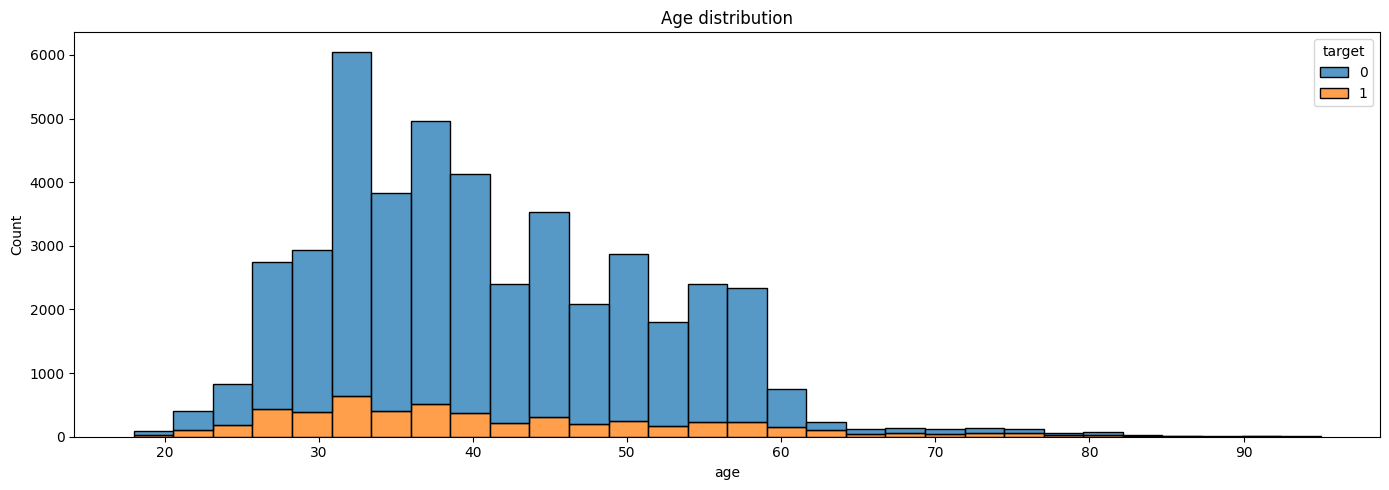

In [40]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.histplot(data=df_model,x="age",hue="target",bins=30, multiple="stack",ax=ax)

ax.set_title("Age distribution")
plt.tight_layout()
plt.show()

#### Categorical Feature Distribution by Target

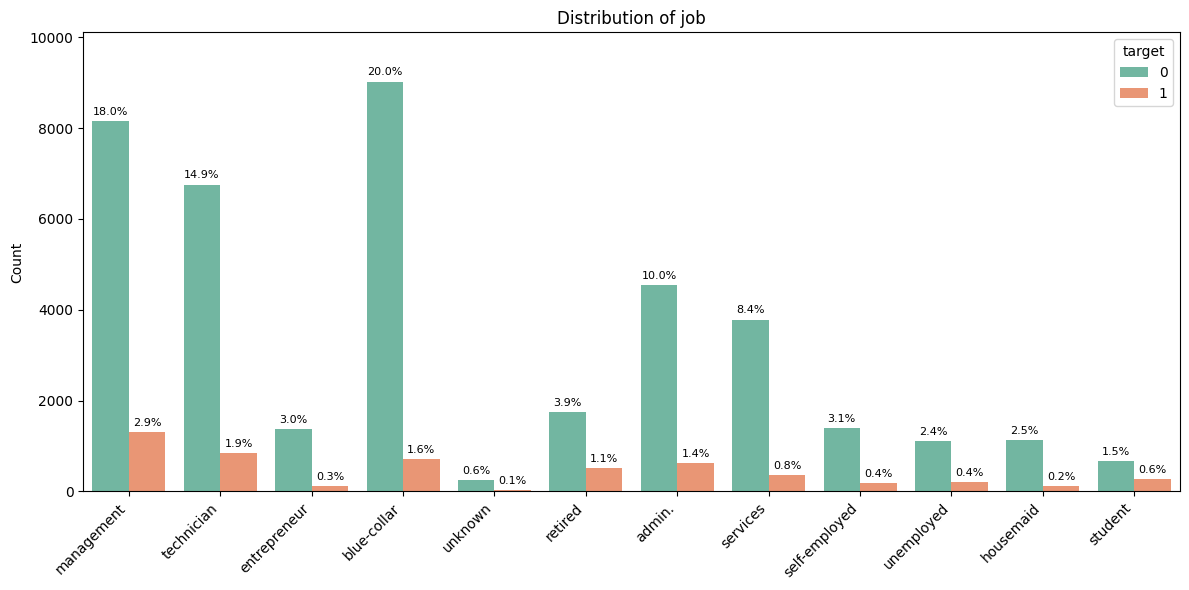

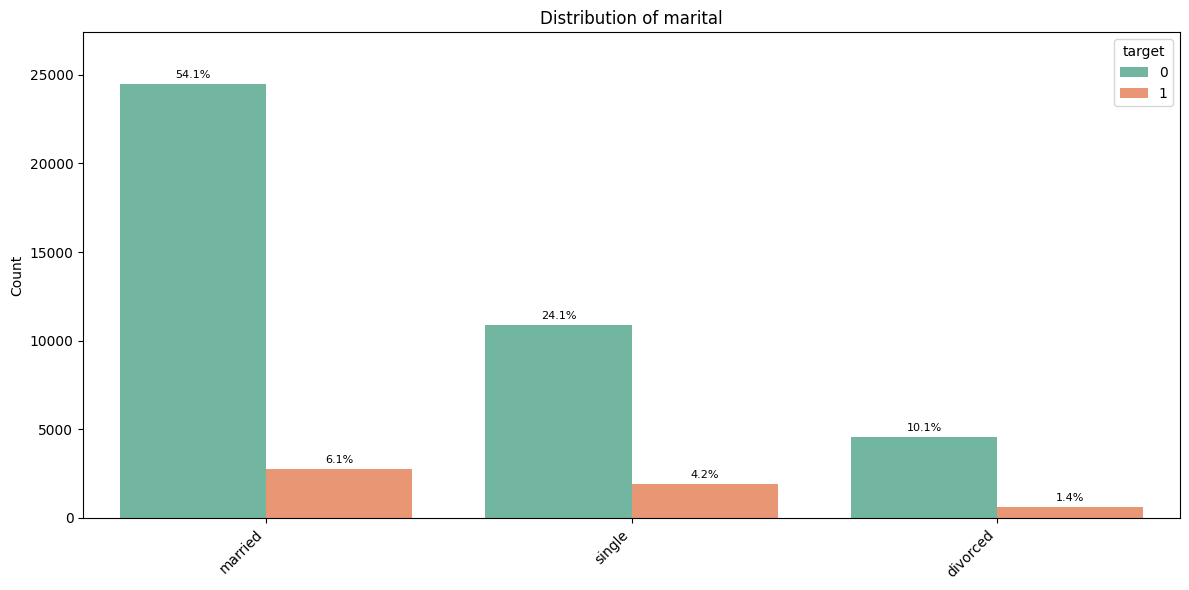

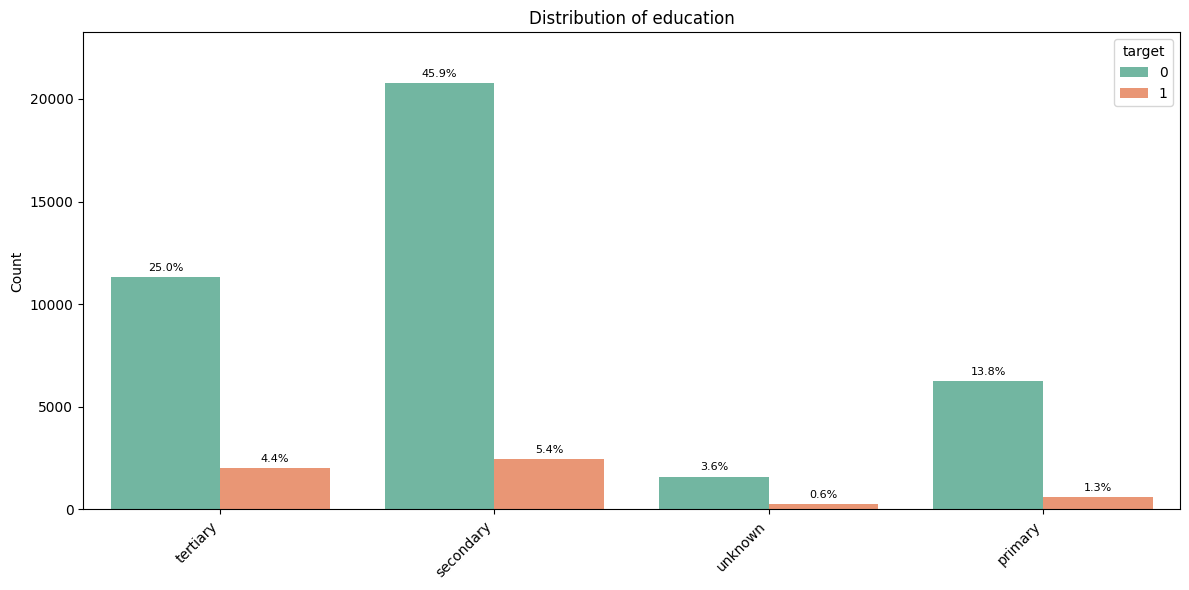

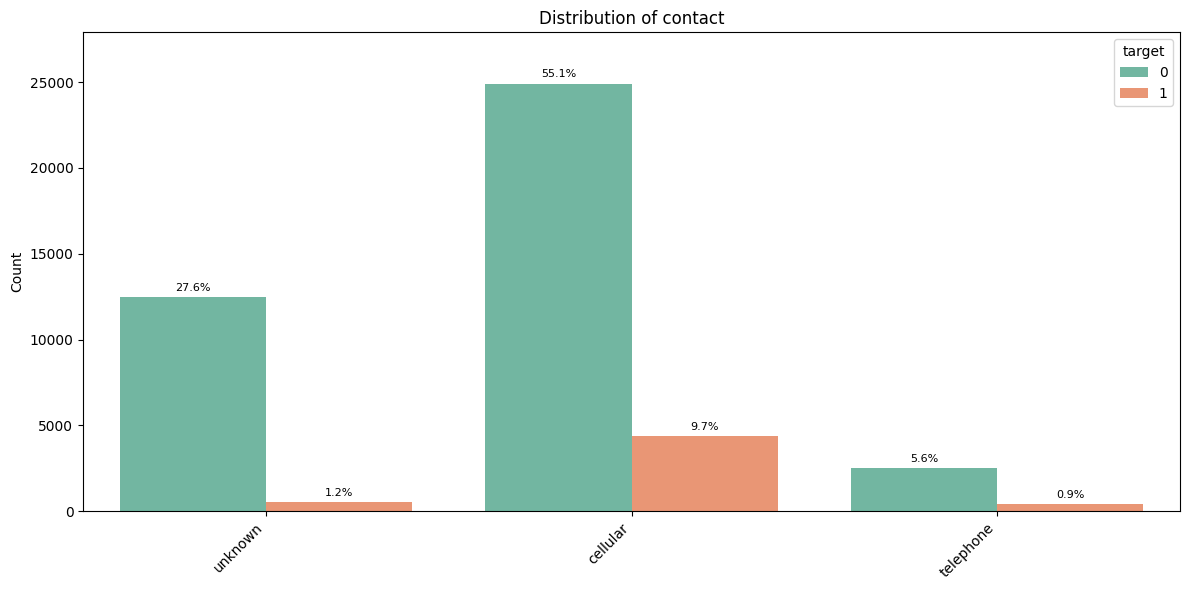

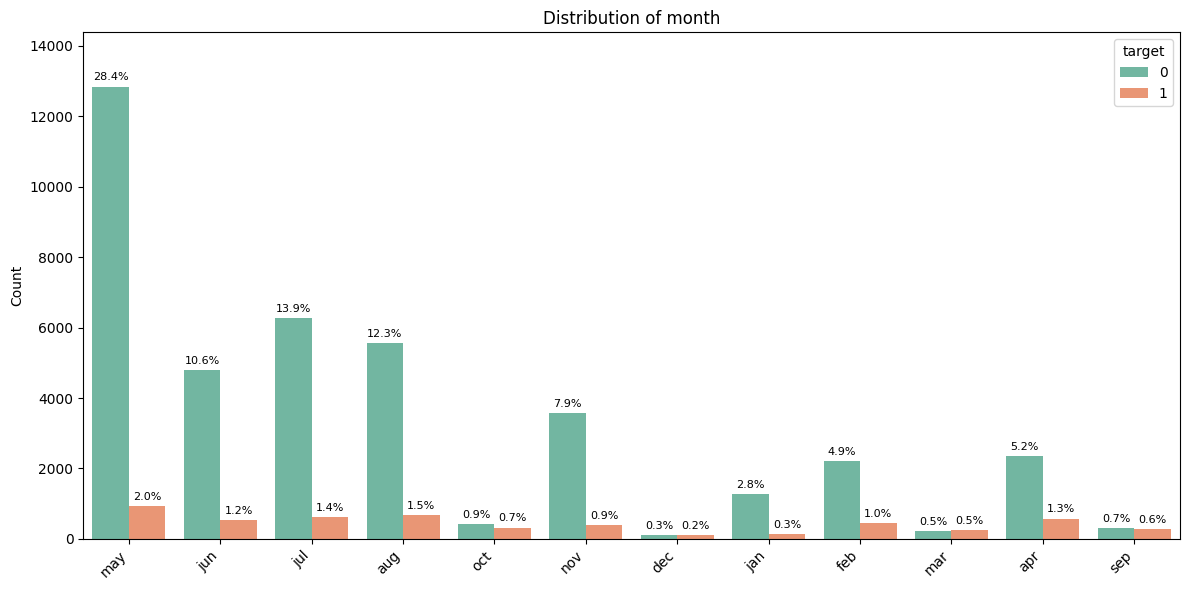

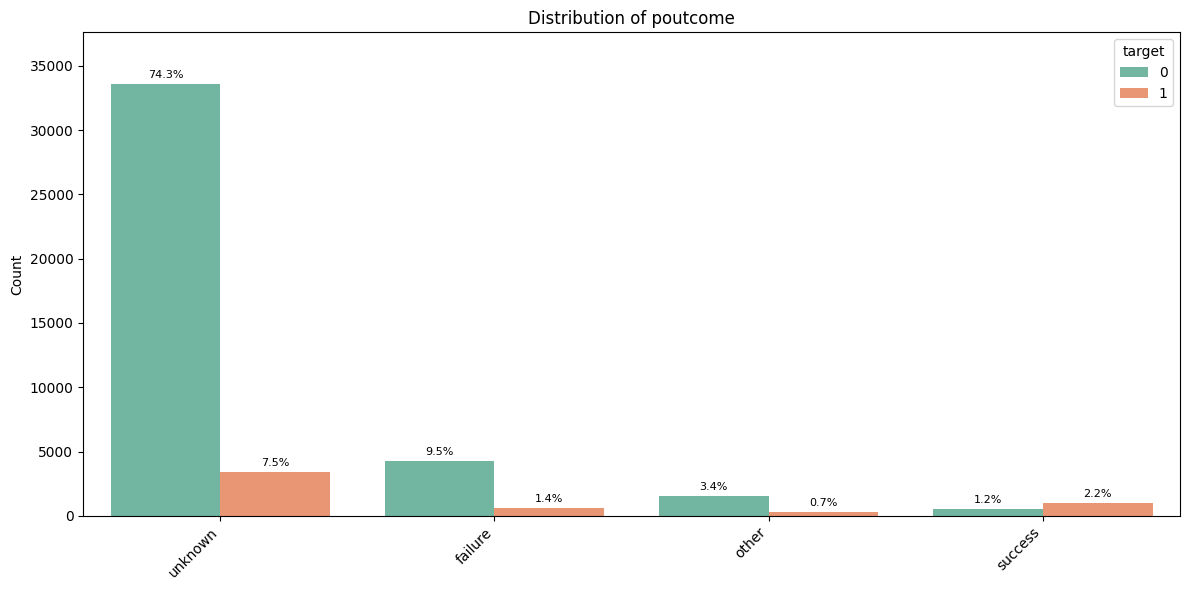

In [41]:
cat_cols_preview = [c for c in ["job", "marital", "education", "contact", "month", "poutcome"] if c in df_model.columns]

for col in cat_cols_preview:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(
        data=df_model,
        x=col,
        hue="target",
        palette="Set2"
    )

    total = len(df_model)
    max_height = max([p.get_height() for p in ax.patches]) if ax.patches else 0

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            pct = 100 * height / total
            ax.annotate(
                f'{pct:.1f}%',
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=8,
                xytext=(0, 3),
                textcoords="offset points"
            )

    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, max_height * 1.12)
    plt.tight_layout()
    plt.show()

#### Analysis

- In the `job` variable, categories such as blue-collar, management, and technician are the most common, while categories like student, unemployed, and unknown appear less often.
- In `marital` and `education`, the majority of customers are married and have secondary education.
- For `contact`, most customers were contacted through cellular communication, while telephone and unknown contact types are less frequent.
- The `month` variable shows that customer contacts are concentrated in a few months, especially May, July, and August.
- In `poutcome`, the `unknown` category is dominant, which suggests that previous campaign outcome information is unavailable for many customers.
- Across all categorical variables, the non-subscribed class remains larger than the subscribed class, which is consistent with the overall imbalance in the target variable.
- Even so, some categories appear to have relatively different subscription patterns, suggesting that categorical features may provide useful predictive information for the models.

## 6. Data Splitting and Preprocessing

The data was split into training, validation, and test sets to separate model development from final evaluation.  
- **Training set:** used to fit the models  
- **Validation set:** used to compare models and tune settings such as the decision threshold  
- **Test set:** kept untouched until the very end to estimate out-of-sample performance  

An 80/20 train-test split was applied first, and the training portion was split again to create the validation set. This setup reduces the risk of overfitting model choices to the final test data.

In [42]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   
    random_state=42,
    stratify=y_train_full
)


### Preprocessing Pipeline Summary

A preprocessing pipeline was used so that each feature type was handled consistently within the modeling workflow.  
- **Numerical features:** median imputation, followed by standard scaling  
- **Categorical features:** most-frequent imputation, followed by one-hot encoding  

Using a `ColumnTransformer` keeps preprocessing and modeling in a single pipeline, which helps prevent data leakage and ensures that the same transformations are applied to validation and test data.

In [43]:

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Evaluation Function

To compare models fairly, a single evaluation function was used for every experiment. It reports the classification metrics and confusion matrix for a given dataset, making performance comparisons more consistent and easier to interpret.

In [44]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    print(f" {model_name} Classification Report ")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

## 7. Models


We compare:
- Logistic Regression
- Random Forest
- XGBoost

### Logistic Regression

- A Logistic Regression model was built using the preprocessing pipeline and trained on the training set.
- After training, predictions were generated on the validation set.
- The evaluation function was then used to assess the model’s performance.
- This made it possible to review the classification report and confusion matrix in a consistent format.

In [45]:
Log =  Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression( max_iter=2000,class_weight="balanced",random_state =42))
])

In [46]:
Log.fit(X_train, y_train)
y_pred_log = Log.predict(X_val)

 Logistic Regression Classification Report 
              precision    recall  f1-score   support

           0       0.94      0.78      0.86      7984
           1       0.28      0.62      0.38      1058

    accuracy                           0.77      9042
   macro avg       0.61      0.70      0.62      9042
weighted avg       0.86      0.77      0.80      9042



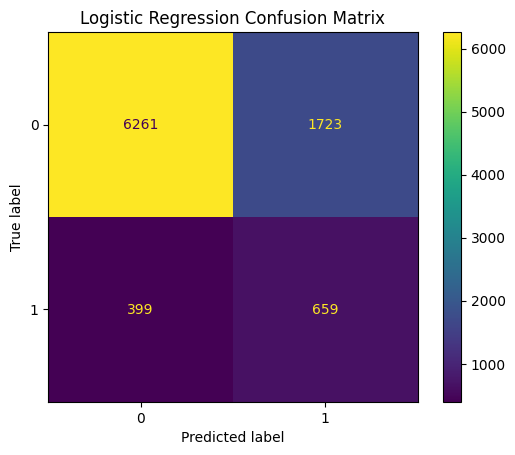

In [47]:
evaluate_model(y_val,y_pred_log,model_name = 'Logistic Regression')

### Random Forest

- A Random Forest model was built using the same preprocessing pipeline and trained on the training set.
- After training, predictions were generated on the validation set.
- The evaluation function was then applied to measure the model’s performance.
- This allowed the classification report and confusion matrix to be displayed in the same format used for Logistic Regression.

In [48]:
Rf=  Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1))
])


In [49]:
Rf.fit(X_train, y_train)
y_pred_Rf = Rf.predict(X_val)

 Random Forest Classification Report 
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      7984
           1       0.52      0.40      0.46      1058

    accuracy                           0.89      9042
   macro avg       0.72      0.68      0.70      9042
weighted avg       0.88      0.89      0.88      9042



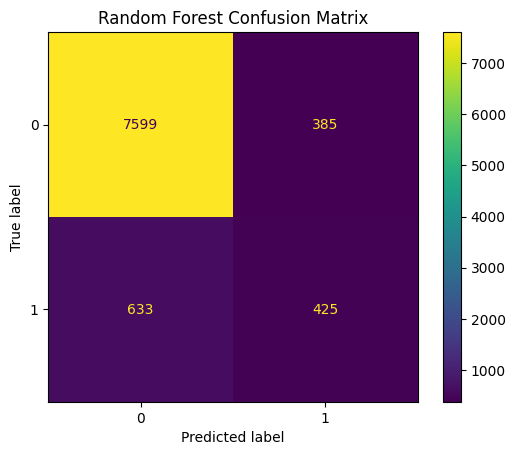

In [50]:
evaluate_model(y_val,y_pred_Rf,model_name = "Random Forest")

### XGBoost

- An XGBoost model was built using the same preprocessing pipeline and trained on the training set.
- This allowed the classification report and confusion matrix to be displayed in a consistent format for comparison with the other models.
- XGBoost was included because it is a powerful boosting algorithm that can capture complex relationships in the data and often performs well on classification tasks.

In [51]:
XGB = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",  XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        random_state=42))
    
])

In [52]:
XGB.fit(X_train, y_train)
y_pred_XGB = XGB.predict(X_val)

 XGBoost Classification Report 
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7984
           1       0.66      0.26      0.37      1058

    accuracy                           0.90      9042
   macro avg       0.79      0.62      0.66      9042
weighted avg       0.88      0.90      0.88      9042



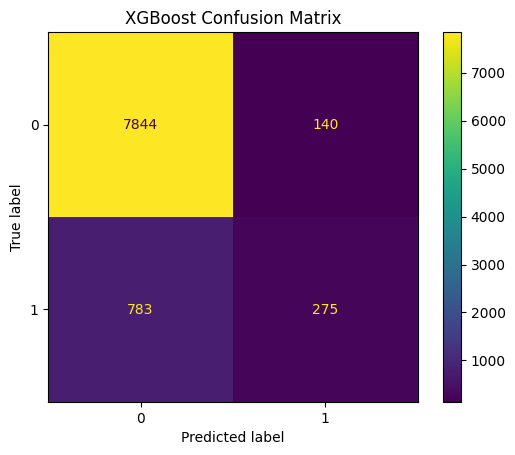

In [53]:
evaluate_model(y_val,y_pred_XGB,model_name = "XGBoost")

### Hyperparameter Tuning

- Hyperparameter tuning was applied to improve the performance of the XGBoost model.
- A `RandomizedSearchCV` procedure was used to test different combinations of key parameters, including the number of estimators, maximum depth, learning rate, and subsample ratio.
- The search was performed using 5-fold cross-validation and evaluated with the F1-score.
- This approach helps identify a better combination of settings without testing every possible parameter combination.
- The best parameter values and the corresponding cross-validation score were then selected for the final tuned model.

In [54]:

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    XGB,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

{'model__subsample': 1.0, 'model__n_estimators': 500, 'model__max_depth': 3, 'model__learning_rate': 0.1}
0.33036703869507156


In [55]:
XGB = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model",  XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.1,
        subsample=1.0,
        random_state=42))
    
])

In [56]:
XGB.fit(X_train, y_train)
predictions = XGB.predict(X_val)

 XGB Classification Report 
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7984
           1       0.64      0.26      0.37      1058

    accuracy                           0.90      9042
   macro avg       0.77      0.62      0.66      9042
weighted avg       0.88      0.90      0.88      9042



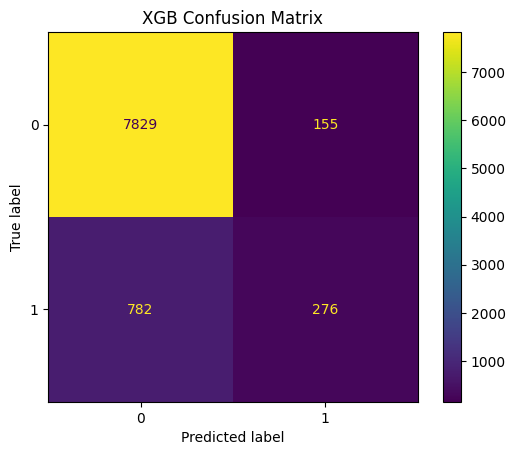

In [57]:
evaluate_model(y_val,predictions,model_name="XGB")

RandomizedSearchCV selected a slightly different set of XGBoost hyperparameters, but the test-set performance changed very little compared with the earlier XGBoost model. In fact, the classification metrics were almost identical at the default threshold, which suggests that hyperparameter tuning added limited improvement in this case.

This is still a useful result: it indicates that the original XGBoost configuration was already close to a strong solution for this dataset. The more meaningful improvement came later from threshold tuning, which produced a better precision-recall balance.

## 8. Threshold Tuning and Model Comparison

Because the classes are imbalanced, the default probability threshold of 0.50 is not necessarily the best choice. Different thresholds were tested on the validation set, and the threshold that produced the highest F1 score was selected. This improves the balance between precision and recall for the positive class.

In [58]:
y_score = XGB.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
threshold_rows = []

for threshold in thresholds:
    y_pred_thr = (y_score >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred_thr, zero_division=0),
        "recall": recall_score(y_val, y_pred_thr, zero_division=0),
        "f1": f1_score(y_val, y_pred_thr, zero_division=0),
        "accuracy": accuracy_score(y_val, y_pred_thr)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_f1_threshold = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]
threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1,accuracy
20,0.25,0.512241,0.514178,0.513208,0.885866
19,0.24,0.503656,0.520794,0.512082,0.883875
18,0.23,0.496448,0.528355,0.511905,0.882106
21,0.26,0.516505,0.502836,0.509579,0.886751
17,0.22,0.483319,0.534026,0.507409,0.878677
15,0.20,0.465504,0.554820,0.506253,0.873369
16,0.21,0.473207,0.542533,0.505504,0.875802
22,0.27,0.517857,0.493384,0.505324,0.886972
14,0.19,0.454201,0.567108,0.504414,0.869608
13,0.18,0.445739,0.578450,0.503497,0.866512


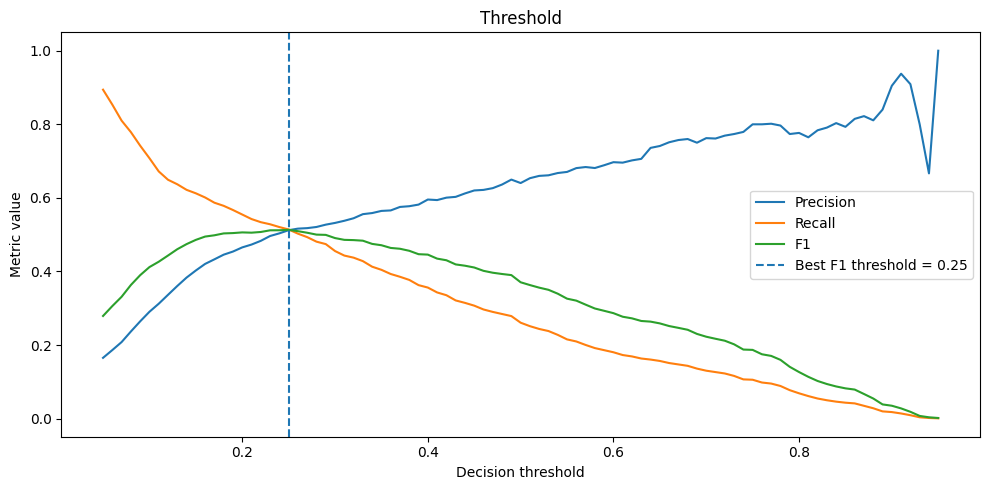

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_f1_threshold, linestyle="--", label=f"Best F1 threshold = {best_f1_threshold:.2f}")
plt.title("Threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.show()

### Threshold Tuning Result

The validation results show that lowering the threshold improves detection of positive cases. The best threshold was **0.25**, which increased recall enough to produce a stronger overall F1 score than the default setting.

## 9. Final Validation Evaluation

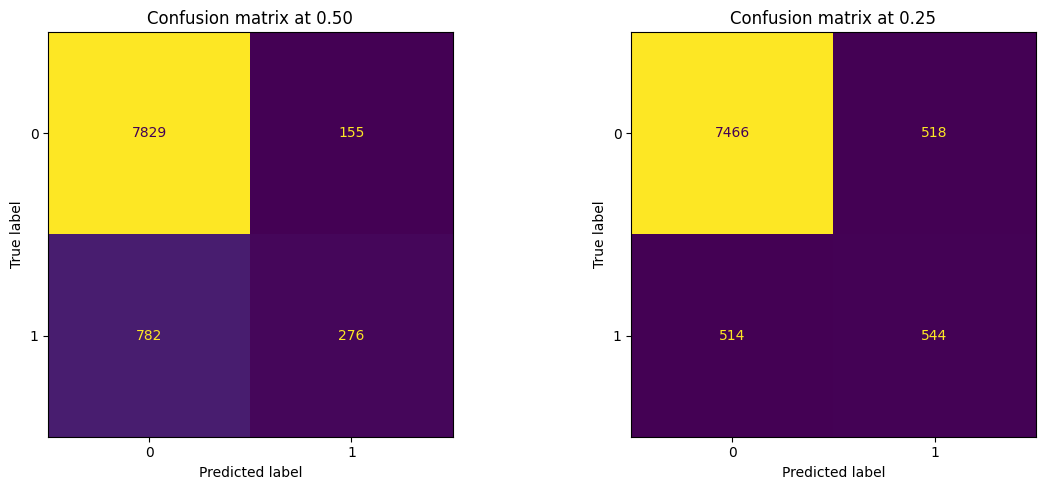

Classification report at tuned threshold
              precision    recall  f1-score   support

           0     0.9356    0.9351    0.9354      7984
           1     0.5122    0.5142    0.5132      1058

    accuracy                         0.8859      9042
   macro avg     0.7239    0.7246    0.7243      9042
weighted avg     0.8861    0.8859    0.8860      9042



In [62]:
y_pred_default = (y_score >= 0.5).astype(int)
y_pred_tuned = (y_score >= best_f1_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_default, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix at 0.50")

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_tuned, ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion matrix at {best_f1_threshold:.2f}")

plt.tight_layout()
plt.show()

print("Classification report at tuned threshold")
print(classification_report(y_val, y_pred_tuned, digits=4))

### Tuned XGBoost Performance

After threshold tuning, XGBoost delivered the best balance between precision and recall among the tested models. This makes it the strongest candidate for the final evaluation, especially since the task places importance on identifying likely subscribers rather than maximizing overall accuracy alone.

### Comparison Table

In [69]:
results = []

def add_metrics(name, y_true, y_pred, y_proba):
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "AP": average_precision_score(y_true, y_proba)
    })


log_proba = Log.predict_proba(X_val)[:, 1]
log_pred = Log.predict(X_val)
add_metrics("Logistic Regression", y_val, log_pred, log_proba)


rf_proba = Rf.predict_proba(X_val)[:, 1]
rf_pred = Rf.predict(X_val)
add_metrics("Random Forest", y_val, rf_pred, rf_proba)

xgb_proba = XGB.predict_proba(X_val)[:, 1]
xgb_pred_default = (xgb_proba >= 0.5).astype(int)
add_metrics("XGBoost (0.50 threshold)", y_val, xgb_pred_default, xgb_proba)

xgb_pred_tuned = (xgb_proba >= best_f1_threshold).astype(int)
add_metrics(f"XGBoost ({best_f1_threshold:.2f} threshold)", y_val, xgb_pred_tuned, xgb_proba)

comparison_df = pd.DataFrame(results).round(4)
comparison_df

,model,accuracy,precision,recall,F1,ROC-AUC,AP
0,Logistic Regression,0.7658,0.2771,0.6229,0.3836,0.7726,0.4133
1,Random Forest,0.8877,0.5264,0.4055,0.4581,0.7960,0.4497
2,XGBoost (0.50 threshold),0.9082,0.7478,0.3251,0.4532,0.8487,0.5677
3,XGBoost (0.25 threshold),0.8958,0.5550,0.5529,0.5540,0.8487,0.5677


### Model Choice

XGBoost was selected as the final model because it achieved the strongest validation performance on the chosen metric. Since the dataset is imbalanced, priority was given to a model that improved positive-class detection while keeping false positives at a manageable level.

## 10. Calibration and Performance Curves

### Calibration Interpretation

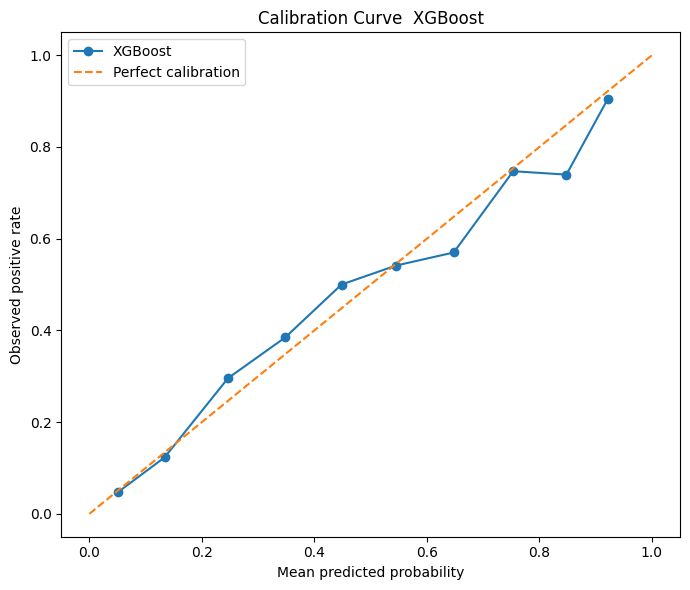

In [64]:
y_proba_XGB = XGB.predict_proba(X_val)[:, 1]

prob_true, prob_pred = calibration_curve(y_val, y_proba_XGB, n_bins=10, strategy="uniform")

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", label="XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Calibration Curve  XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

The calibration curve suggests that the model’s predicted probabilities are reasonably aligned with observed outcomes across most ranges. Some deviation appears at higher probability levels, which may indicate mild overconfidence, but overall the probability estimates remain usable for ranking and targeting decisions.

### Curves: ROC and Recall

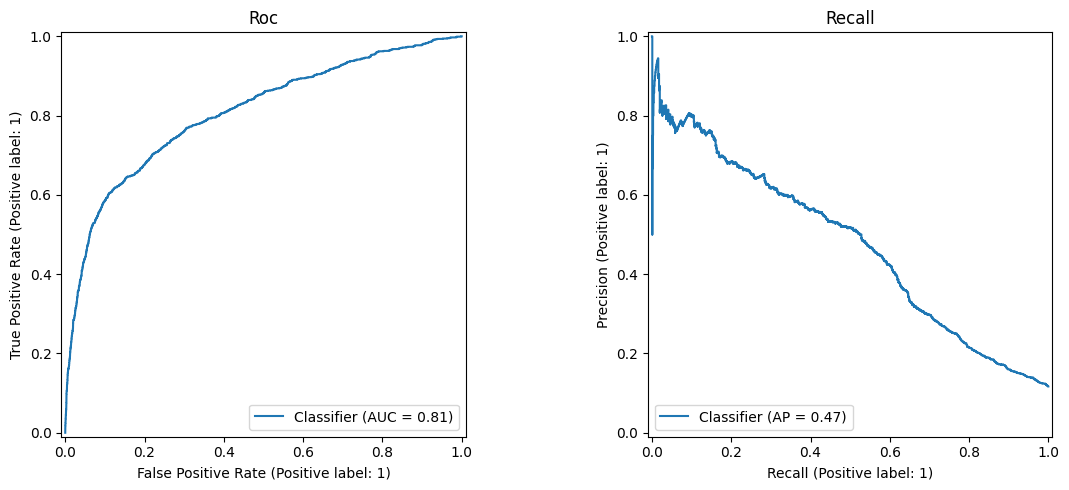

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_val, y_score, ax=axes[0])
axes[0].set_title('Roc')

PrecisionRecallDisplay.from_predictions(y_val, y_score, ax=axes[1])
axes[1].set_title('Recall')


plt.tight_layout()
plt.show()

The ROC curve shows that the model has good discriminative performance, with an AUC of 0.81, meaning it can separate likely subscribers from non-subscribers reasonably well. The Precision-Recall curve gives a more informative view of performance on the positive class and shows an average precision of 0.46, indicating that the model is useful for identifying likely subscribers,